In [131]:
using Plots

In [97]:
using CovidSim_ilm

In [98]:
cd(joinpath(homedir(),"Dropbox/Covid Modeling/Covid-ILM/source"))

In [99]:
# set locale and number of days
locale = 38015
ndays = 720

720

In [100]:
alldat = setup(ndays, [locale]; 
    dovax=true,
    paramdir="../parameters", 
    geofilename="../data/geo2data.csv",
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantsfilename = "variants.yml"
    );

In [101]:
locdat = alldat.dat["popdat"][locale]

Table with 18 columns and 95626 rows:
      pid  status     agegrp   cond     duration  variant  recovday  deadday  ⋯
    ┌─────────────────────────────────────────────────────────────────────────
 1  │ 1    unexposed  age0_19  notsick  0        default  0         0        ⋯
 2  │ 2    unexposed  age0_19  notsick  0        default  0         0        ⋯
 3  │ 3    unexposed  age0_19  notsick  0        default  0         0        ⋯
 4  │ 4    unexposed  age0_19  notsick  0        default  0         0        ⋯
 5  │ 5    unexposed  age0_19  notsick  0        default  0         0        ⋯
 6  │ 6    unexposed  age0_19  notsick  0        default  0         0        ⋯
 7  │ 7    unexposed  age0_19  notsick  0        default  0         0        ⋯
 8  │ 8    unexposed  age0_19  notsick  0        default  0         0        ⋯
 9  │ 9    unexposed  age0_19  notsick  0        default  0         0        ⋯
 10 │ 10   unexposed  age0_19  notsick  0        default  0         0        ⋯
 11 │ 11   un

# Create a seed case

In [102]:
seed_1_6 = seed_case_gen(1, [0,3,3,0,0], 1, nil, :base, agegrps)

(::CovidSim_ilm.var"#runcase#66"{CovidSim_ilm.var"#runcase#65#67"{Int64, Vector{Int64}, Int64, condition, Symbol, NTuple{5, agegrp}}}) (generic function with 1 method)

# Run a simulation

In [142]:
result_dict, series = run_a_sim(ndays, locale; 
    dovax=false, 
    dovariant=false,
    paramdir = "../parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantsfilename = "variants.yml",
    showr0=false, 
    silent=true, 
    runcases=[seed_1_6]);

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.3754632319999999, 0, 1.2838587059999997, 0.6752121280000002, 1.1828727079999999)


In [104]:
result_dict[:dat]["popdat"][38015]

Table with 18 columns and 95626 rows:
      pid  status     agegrp   cond     duration  variant  recovday  deadday  ⋯
    ┌─────────────────────────────────────────────────────────────────────────
 1  │ 1    recovered  age0_19  mild     14       default  550       0        ⋯
 2  │ 2    recovered  age0_19  mild     14       default  617       0        ⋯
 3  │ 3    unexposed  age0_19  notsick  0        default  0         0        ⋯
 4  │ 4    unexposed  age0_19  notsick  0        default  0         0        ⋯
 5  │ 5    recovered  age0_19  nil      9        default  653       0        ⋯
 6  │ 6    unexposed  age0_19  notsick  0        default  0         0        ⋯
 7  │ 7    recovered  age0_19  mild     14       default  532       0        ⋯
 8  │ 8    unexposed  age0_19  notsick  0        default  0         0        ⋯
 9  │ 9    unexposed  age0_19  notsick  0        default  0         0        ⋯
 10 │ 10   recovered  age0_19  mild     14       default  492       0        ⋯
 11 │ 11   re

# Plot results

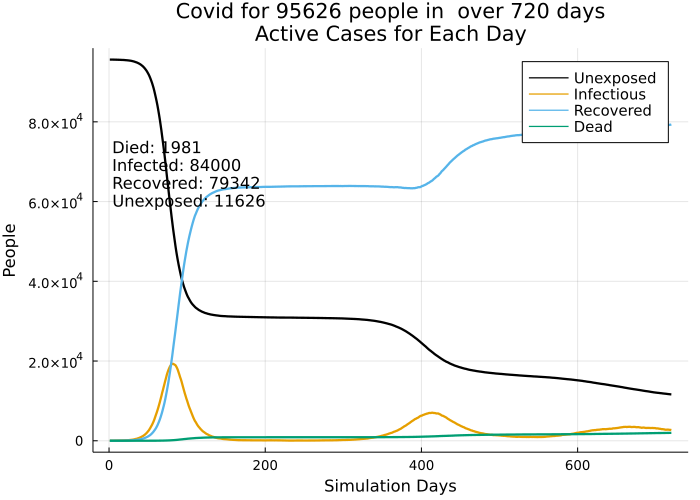

In [143]:
cumplot(series, locale)

In [129]:
expdecay(t,h) = exp(-(log(2)/h) * t)  

expdecay (generic function with 2 methods)

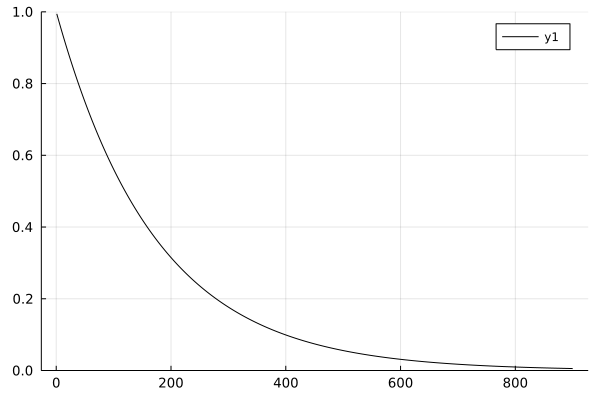

In [136]:
plot(expdecay.(1:900, 120), ylim=(0.0, 1.0))